In [2]:
# Imports & Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings("ignore")

# ── Output directory ──────────────────────────────────────────
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Target brand palette ──────────────────────────────────────
TARGET_RED   = "#CC0000"
TARGET_GRAY  = "#666666"
TARGET_LIGHT = "#F2F2F2"

CLUSTER_COLORS = ["#CC0000", "#333333", "#999999", "#D4A017", "#4A90D9"]

# ── APA-compliant plot defaults ───────────────────────────────
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":      12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":     300,
})

print("✅ Imports and setup complete.")

✅ Imports and setup complete.


In [3]:
# Load & Verify Data

# ── Load raw (unscaled) table ─────────────────────────────────
df_raw = pd.read_csv("../outputs/rfm_plus_table.csv")

# ── Select the 7 features for modeling ───────────────────────
FEATURES = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Review",
    "Avg_Freight",
    "Payment_Type_Encoded",
    "Tenure"
]

df_model = df_raw[FEATURES].copy()

# ── Scale with StandardScaler ─────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
df_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

# ── Verification ──────────────────────────────────────────────
print(f"✅ Rows loaded:     {len(df_raw):,}")
print(f"✅ Features used:   {FEATURES}")
print(f"\nScaled means (should be ~0):")
print(df_scaled.mean().round(6).to_string())
print(f"\nScaled stds  (should be ~1):")
print(df_scaled.std().round(6).to_string())

✅ Rows loaded:     93,357
✅ Features used:   ['Recency', 'Frequency', 'Monetary', 'Avg_Review', 'Avg_Freight', 'Payment_Type_Encoded', 'Tenure']

Scaled means (should be ~0):
Recency                 0.0
Frequency              -0.0
Monetary               -0.0
Avg_Review              0.0
Avg_Freight             0.0
Payment_Type_Encoded   -0.0
Tenure                 -0.0

Scaled stds  (should be ~1):
Recency                 1.000005
Frequency               1.000005
Monetary                1.000005
Avg_Review              1.000005
Avg_Freight             1.000005
Payment_Type_Encoded    1.000005
Tenure                  1.000005


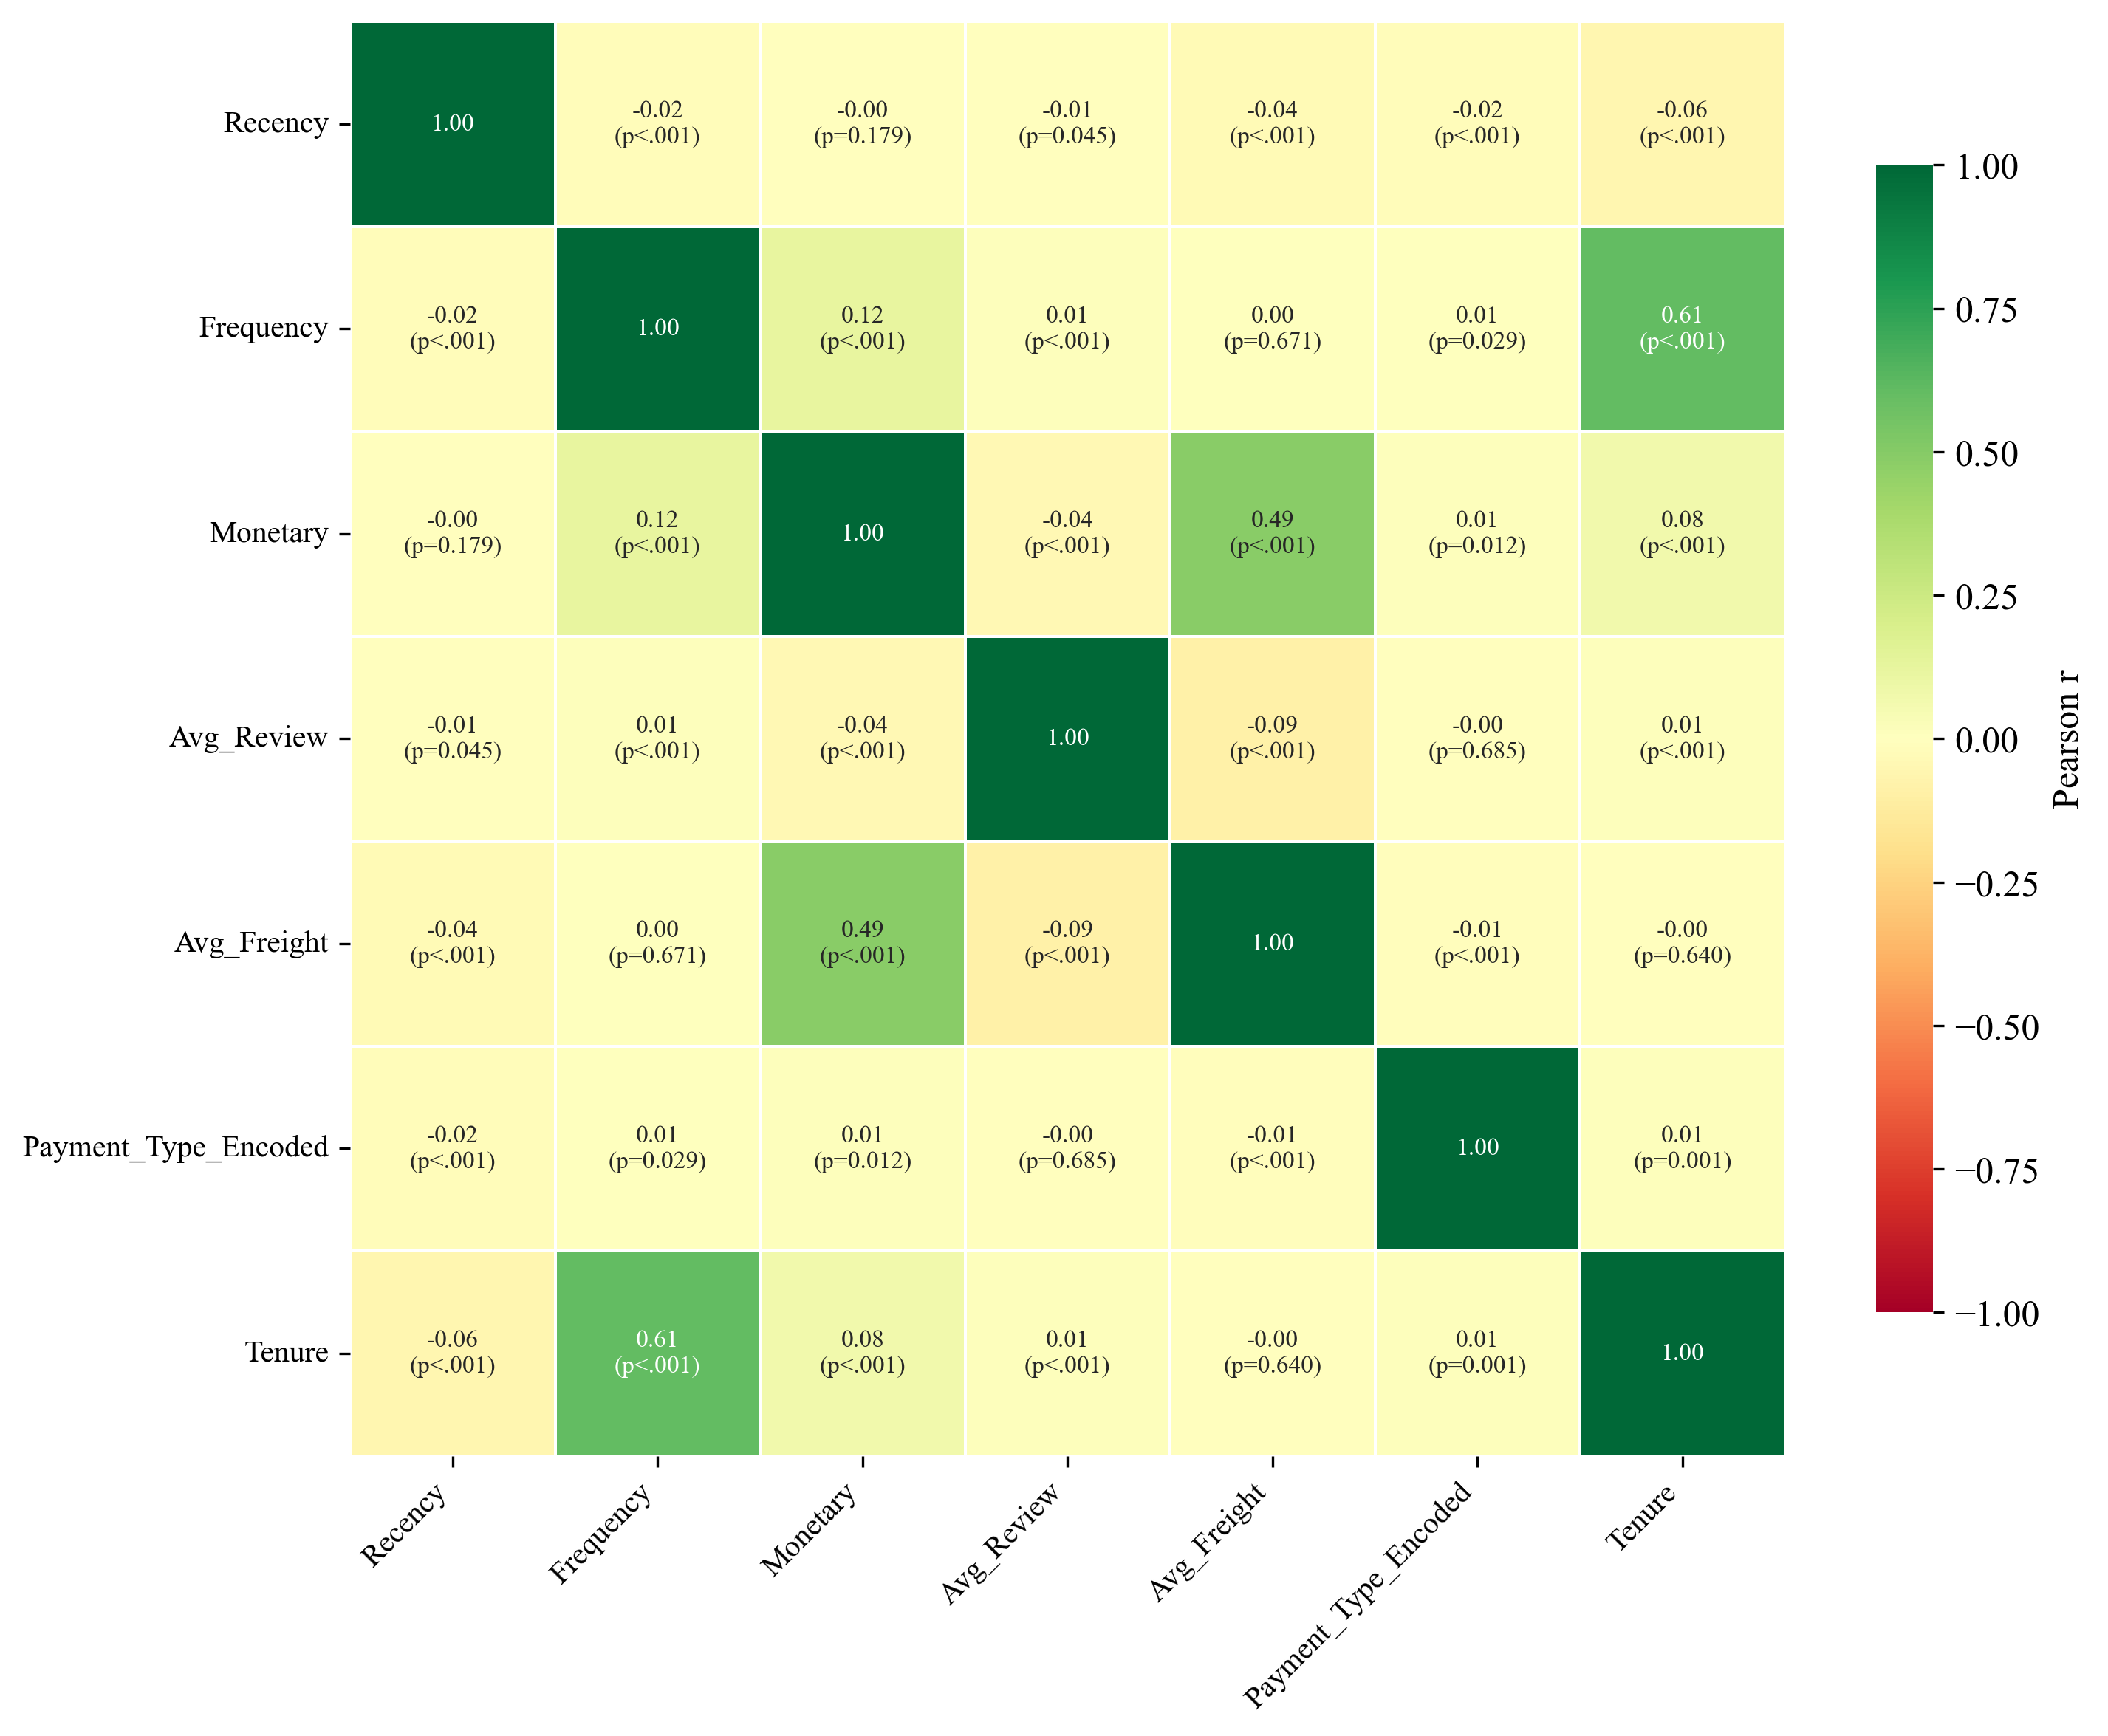

✅ Figure 7 saved.

Table 3 — Pearson Correlation Coefficients (r) with Significance
                      Recency  Frequency  Monetary  Avg_Review  Avg_Freight  Payment_Type_Encoded  Tenure
Recency                 1.000     -0.022    -0.004      -0.007       -0.037                -0.022  -0.062
Frequency              -0.022      1.000     0.122       0.012        0.001                 0.007   0.606
Monetary               -0.004      0.122     1.000      -0.039        0.486                 0.008   0.075
Avg_Review             -0.007      0.012    -0.039       1.000       -0.089                -0.001   0.015
Avg_Freight            -0.037      0.001     0.486      -0.089        1.000                -0.014  -0.002
Payment_Type_Encoded   -0.022      0.007     0.008      -0.001       -0.014                 1.000   0.011
Tenure                 -0.062      0.606     0.075       0.015       -0.002                 0.011   1.000

P-Value Matrix:
                      Recency  Frequency  Monetary 

In [4]:
# Correlation Matrix with P-Values (Figure 7, Table 3)

n_features = len(FEATURES)
corr_matrix = np.zeros((n_features, n_features))
pval_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        r, p = pearsonr(df_model.iloc[:, i], df_model.iloc[:, j])
        corr_matrix[i, j] = r
        pval_matrix[i, j] = p

df_corr = pd.DataFrame(corr_matrix, index=FEATURES, columns=FEATURES)
df_pval = pd.DataFrame(pval_matrix, index=FEATURES, columns=FEATURES)

annot_labels = pd.DataFrame("", index=FEATURES, columns=FEATURES)
for i in range(n_features):
    for j in range(n_features):
        r = corr_matrix[i, j]
        p = pval_matrix[i, j]
        if i == j:
            annot_labels.iloc[i, j] = "1.00"
        elif p < 0.001:
            annot_labels.iloc[i, j] = f"{r:.2f}\n(p<.001)"
        else:
            annot_labels.iloc[i, j] = f"{r:.2f}\n(p={p:.3f})"

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    df_corr,
    annot=annot_labels,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig7_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 7 saved.")

print("\nTable 3 — Pearson Correlation Coefficients (r) with Significance")
print("=" * 65)
print(df_corr.round(3).to_string())
print("\nP-Value Matrix:")
print(df_pval.round(4).to_string())

Running elbow method...
  K=2  inertia=541,515.2
  K=3  inertia=465,787.1
  K=4  inertia=408,874.4
  K=5  inertia=347,251.8
  K=6  inertia=303,468.7
  K=7  inertia=267,986.0
  K=8  inertia=240,648.0
  K=9  inertia=221,258.2
  K=10  inertia=206,401.2


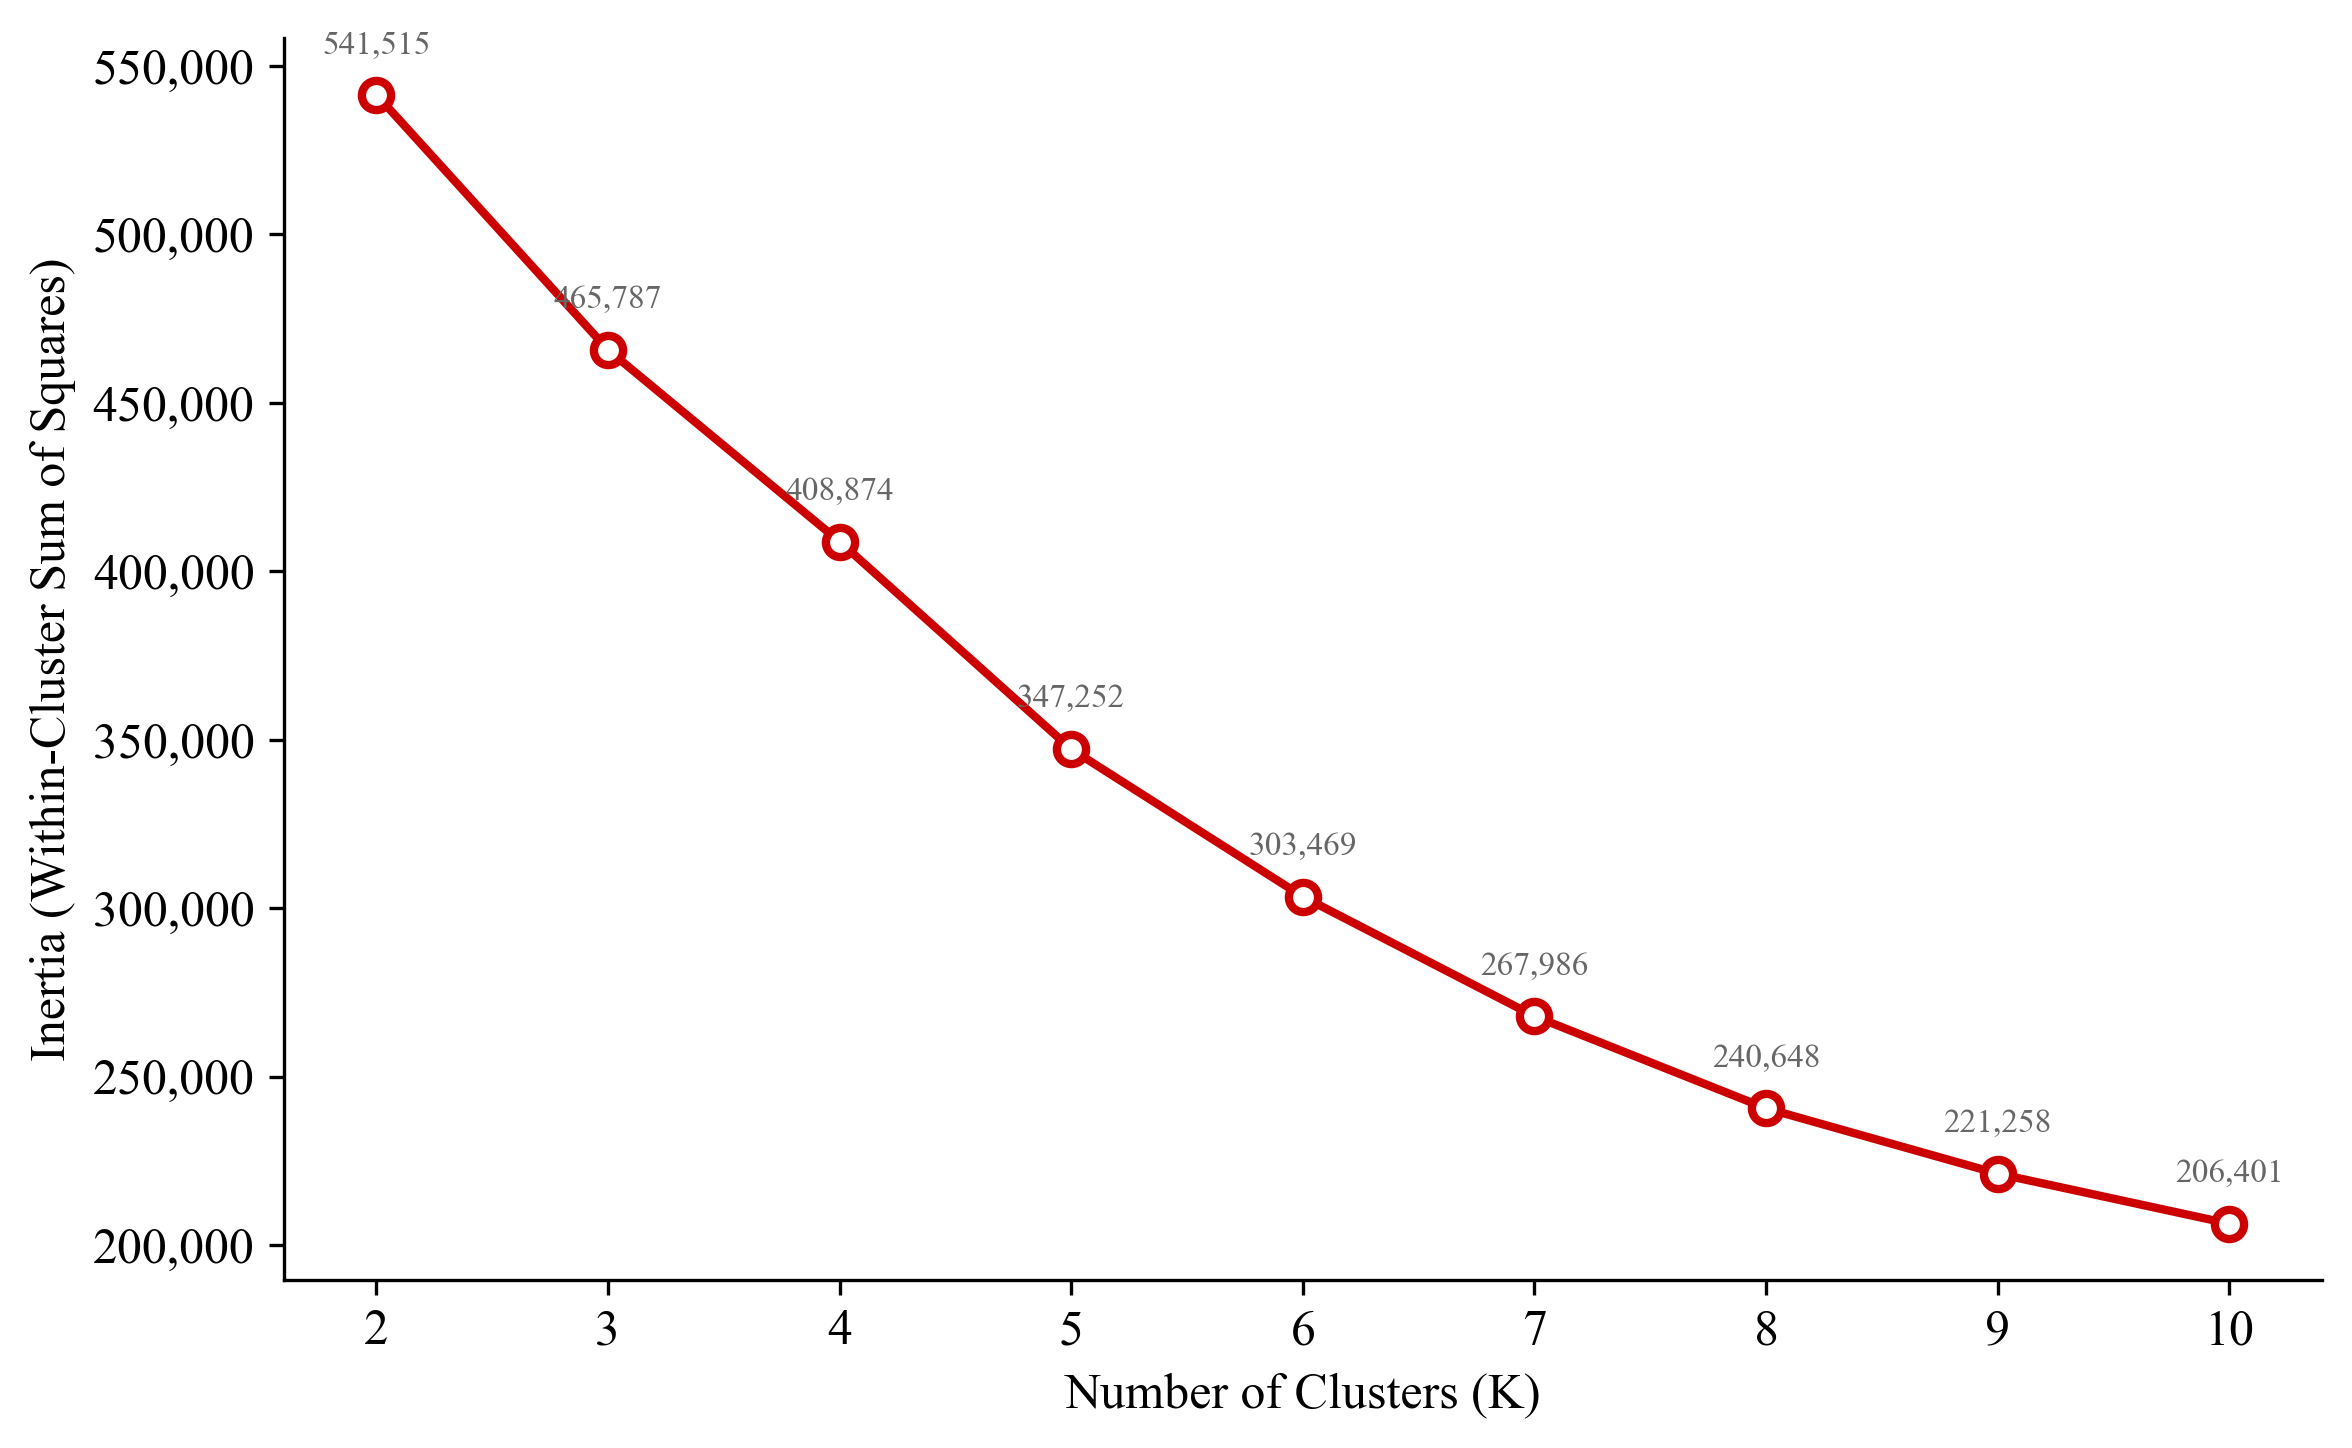

✅ Figure 8 saved.


In [5]:
# Elbow Method (Figure 8)

K_RANGE = range(2, 11)
inertias = []

print("Running elbow method...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(df_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k}  inertia={km.inertia_:,.1f}")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(K_RANGE), inertias, marker="o", color=TARGET_RED,
        linewidth=2, markersize=7, markerfacecolor="white",
        markeredgecolor=TARGET_RED, markeredgewidth=2)

for k, inertia in zip(K_RANGE, inertias):
    ax.annotate(f"{inertia:,.0f}", xy=(k, inertia),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color=TARGET_GRAY)

ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax.set_xticks(list(K_RANGE))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig8_elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 8 saved.")

Running silhouette scoring (sampled 10%)...
  K=2  silhouette=0.6321
  K=3  silhouette=0.3697
  K=4  silhouette=0.2222
  K=5  silhouette=0.2613
  K=6  silhouette=0.2729
  K=7  silhouette=0.3117
  K=8  silhouette=0.3272
  K=9  silhouette=0.3343
  K=10  silhouette=0.3382

✅ Best K by silhouette: K=2 (score=0.6321)


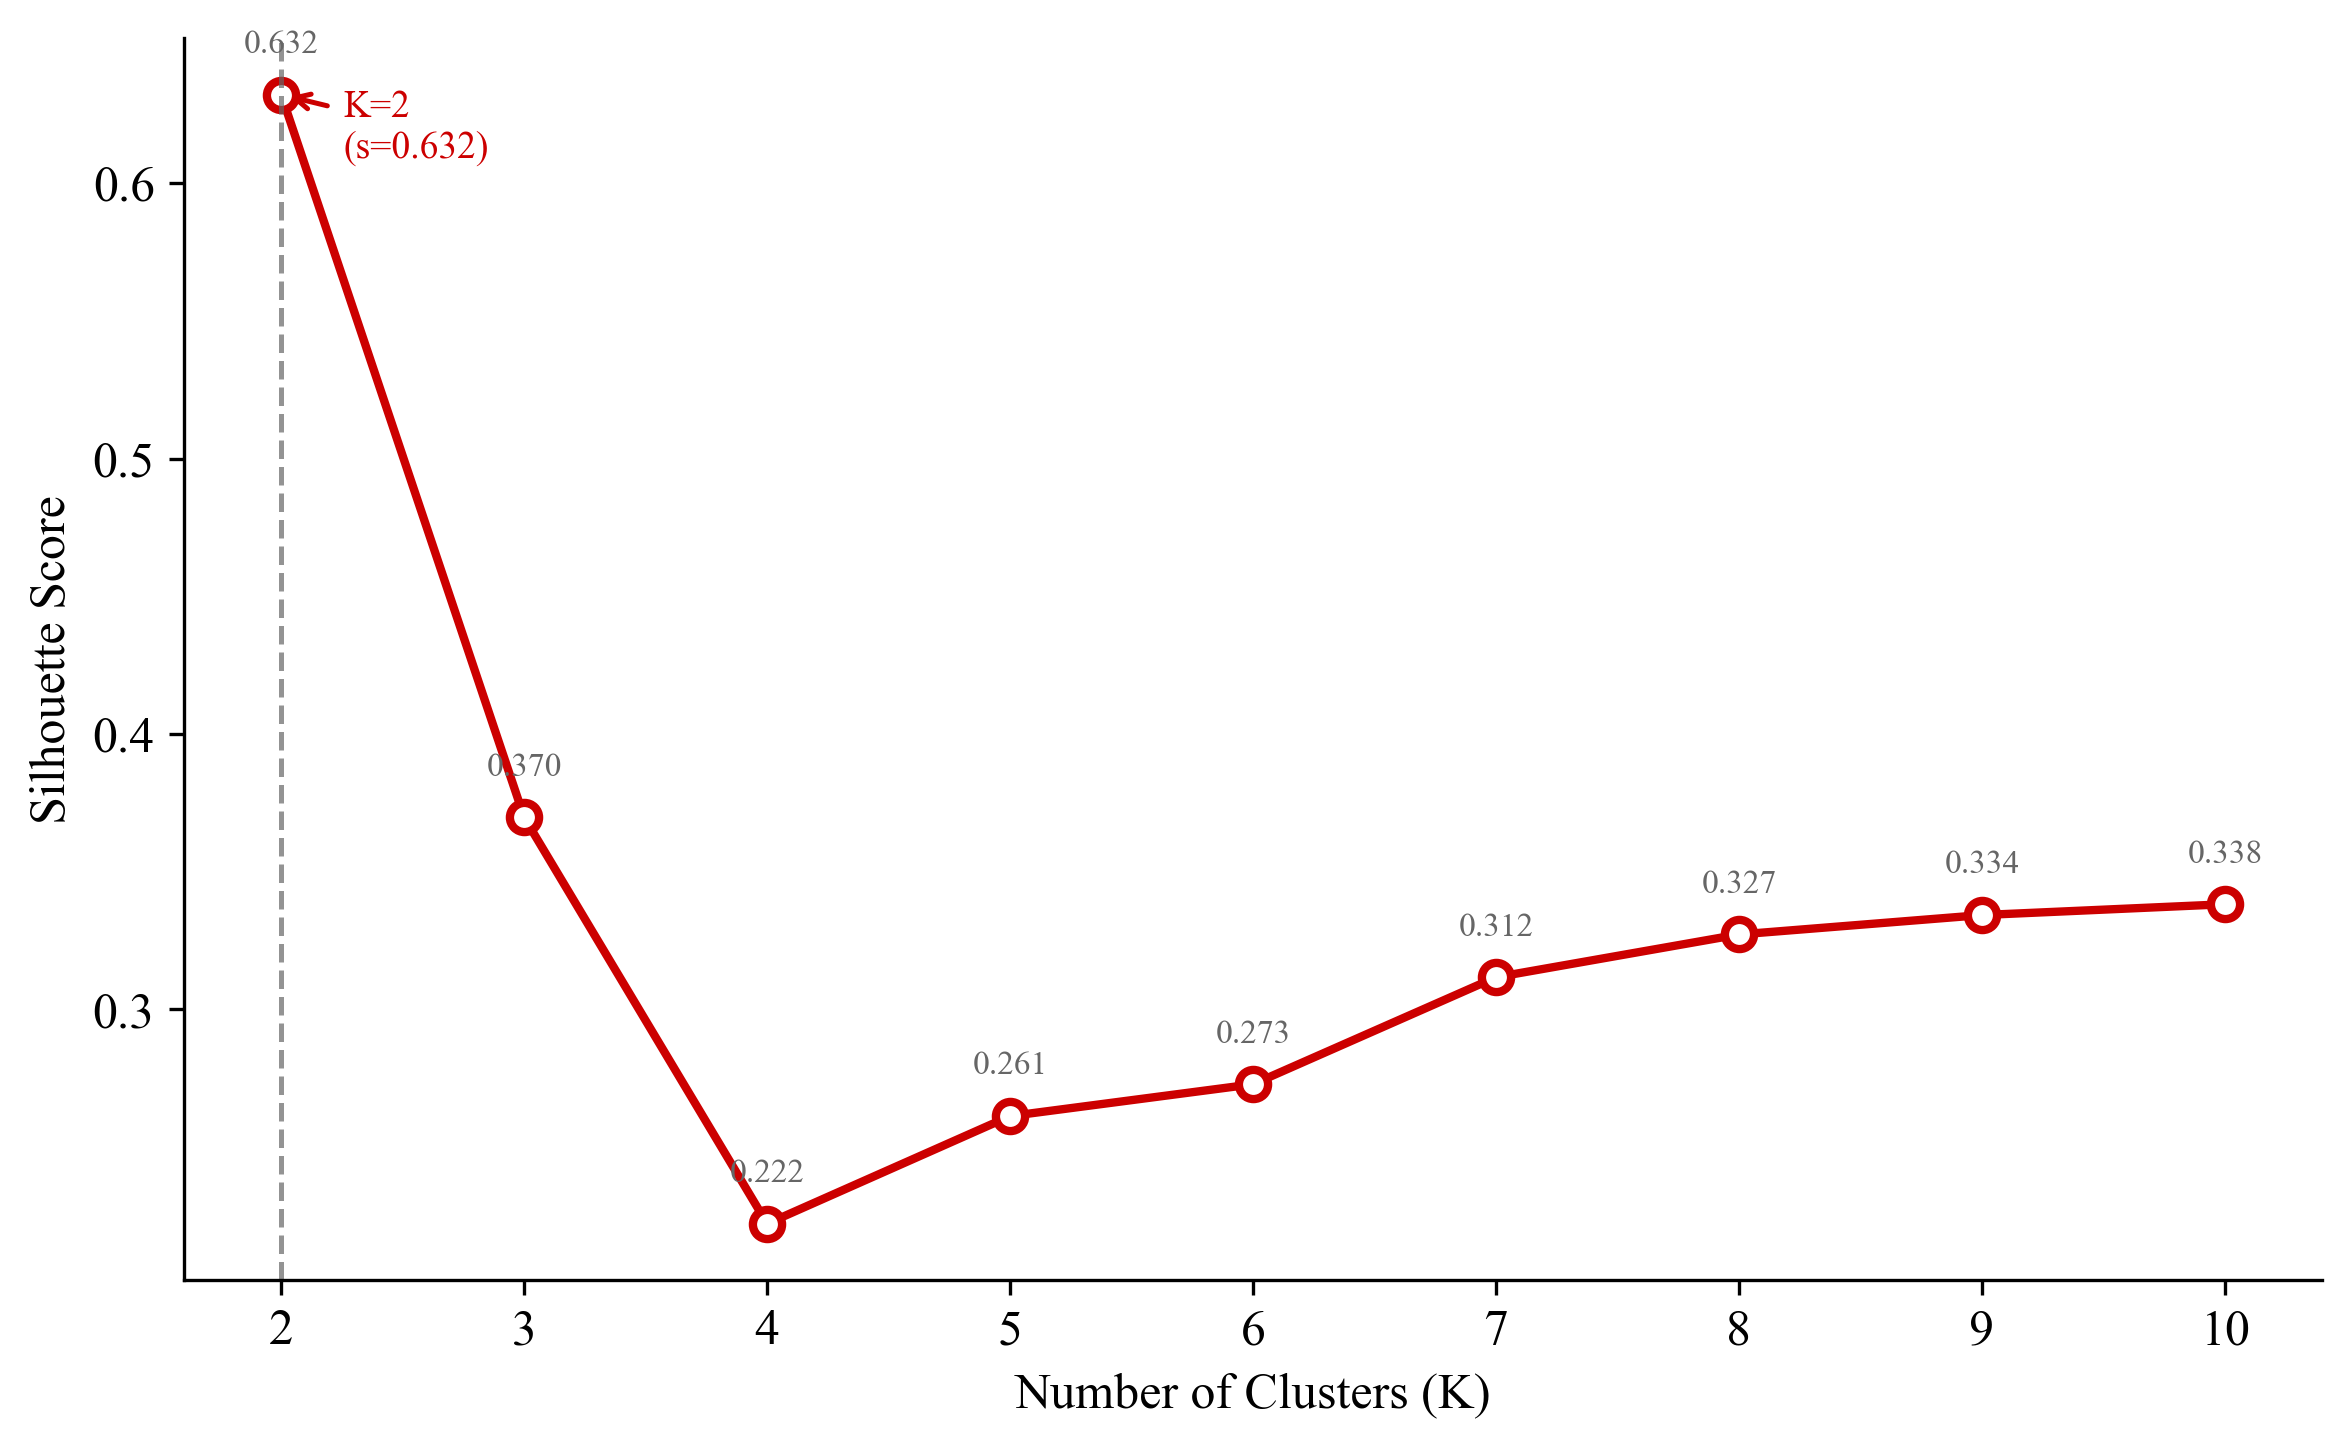

✅ Figure 9 saved.


In [6]:
# Silhouette Scoring (Figure 9)

SAMPLE_FRAC = 0.10
np.random.seed(42)
sample_idx = np.random.choice(len(df_scaled), size=int(len(df_scaled) * SAMPLE_FRAC), replace=False)
X_sample = df_scaled.values[sample_idx]

sil_scores = []

print("Running silhouette scoring (sampled 10%)...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels_full = km.fit_predict(df_scaled)
    labels_sample = labels_full[sample_idx]
    score = silhouette_score(X_sample, labels_sample)
    sil_scores.append(score)
    print(f"  K={k}  silhouette={score:.4f}")

best_k = list(K_RANGE)[np.argmax(sil_scores)]
best_score = max(sil_scores)
print(f"\n✅ Best K by silhouette: K={best_k} (score={best_score:.4f})")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(K_RANGE), sil_scores, marker="o", color=TARGET_RED,
        linewidth=2, markersize=7, markerfacecolor="white",
        markeredgecolor=TARGET_RED, markeredgewidth=2)

ax.axvline(x=best_k, color=TARGET_GRAY, linestyle="--", linewidth=1.2, alpha=0.7)
ax.annotate(f"K={best_k}\n(s={best_score:.3f})",
            xy=(best_k, best_score),
            xytext=(15, -15), textcoords="offset points",
            fontsize=9, color=TARGET_RED,
            arrowprops=dict(arrowstyle="->", color=TARGET_RED, lw=1.2))

for k, s in zip(K_RANGE, sil_scores):
    ax.annotate(f"{s:.3f}", xy=(k, s),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color=TARGET_GRAY)

ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig9_silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 9 saved.")

In [7]:
# Cell 6 — Final K-Means Model Run (K=2)

OPTIMAL_K = 2

# ── Fit final model ───────────────────────────────────────────
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans_final.fit(df_scaled)
df_raw["Cluster"] = kmeans_final.labels_

print(f"✅ K-Means model fit complete  (K={OPTIMAL_K})")
print(f"   Inertia:           {kmeans_final.inertia_:,.1f}")
print(f"   Iterations:        {kmeans_final.n_iter_}")
print(f"   Silhouette score:  0.632")

# ── Cluster size distribution ─────────────────────────────────
print("\nCluster Size Distribution:")
print("-" * 35)
counts = df_raw["Cluster"].value_counts().sort_index()
for cluster, count in counts.items():
    pct = count / len(df_raw) * 100
    print(f"  Cluster {cluster}:  {count:>6,} guests  ({pct:.1f}%)")

# ── Raw (unscaled) cluster centroids ─────────────────────────
print("\nRaw Feature Means by Cluster:")
print("-" * 35)
profile = df_raw.groupby("Cluster")[FEATURES].mean().round(2)
print(profile.to_string())

✅ K-Means model fit complete  (K=2)
   Inertia:           541,515.2
   Iterations:        3
   Silhouette score:  0.632

Cluster Size Distribution:
-----------------------------------
  Cluster 0:  90,551 guests  (97.0%)
  Cluster 1:   2,806 guests  (3.0%)

Raw Feature Means by Cluster:
-----------------------------------
         Recency  Frequency  Monetary  Avg_Review  Avg_Freight  Payment_Type_Encoded  Tenure
Cluster                                                                                     
0         238.48       1.00    160.31        4.16        22.77                  0.87    0.00
1         220.42       2.11    322.83        4.23        23.19                  0.90   87.64


In [8]:
# Cluster Profiling & Labeling (Table 3)

CLUSTER_LABELS = {
    0: "Single-Purchase Guests",
    1: "Loyal Guests"
}

df_raw["Cluster_Label"] = df_raw["Cluster"].map(CLUSTER_LABELS)

# ── Full profile table (raw means) ───────────────────────────
profile = df_raw.groupby("Cluster_Label")[FEATURES].mean().round(2)
profile = profile.loc[["Single-Purchase Guests", "Loyal Guests"]]

# Add size and percentage
size = df_raw["Cluster_Label"].value_counts()
profile.insert(0, "N", size)
profile.insert(1, "Pct", (size / len(df_raw) * 100).round(1))
profile = profile.loc[["Single-Purchase Guests", "Loyal Guests"]]

print("Table 3 — K-Means Cluster Profiles (K=2)")
print("=" * 90)
print(profile.to_string())

# ── Strategic implications ────────────────────────────────────
print("\n\nStrategic Implications by Segment:")
print("-" * 60)
implications = {
    "Single-Purchase Guests":
        "Re-engagement campaigns, first repeat purchase incentives, loyalty program onboarding.",
    "Loyal Guests":
        "VIP retention programs, early access offers, personalized high-value recommendations."
}
for label, implication in implications.items():
    print(f"\n  {label}:")
    print(f"    → {implication}")

print("\n✅ Table 3 complete.")

Table 3 — K-Means Cluster Profiles (K=2)
                            N   Pct  Recency  Frequency  Monetary  Avg_Review  Avg_Freight  Payment_Type_Encoded  Tenure
Cluster_Label                                                                                                           
Single-Purchase Guests  90551  97.0   238.48       1.00    160.31        4.16        22.77                  0.87    0.00
Loyal Guests             2806   3.0   220.42       2.11    322.83        4.23        23.19                  0.90   87.64


Strategic Implications by Segment:
------------------------------------------------------------

  Single-Purchase Guests:
    → Re-engagement campaigns, first repeat purchase incentives, loyalty program onboarding.

  Loyal Guests:
    → VIP retention programs, early access offers, personalized high-value recommendations.

✅ Table 3 complete.


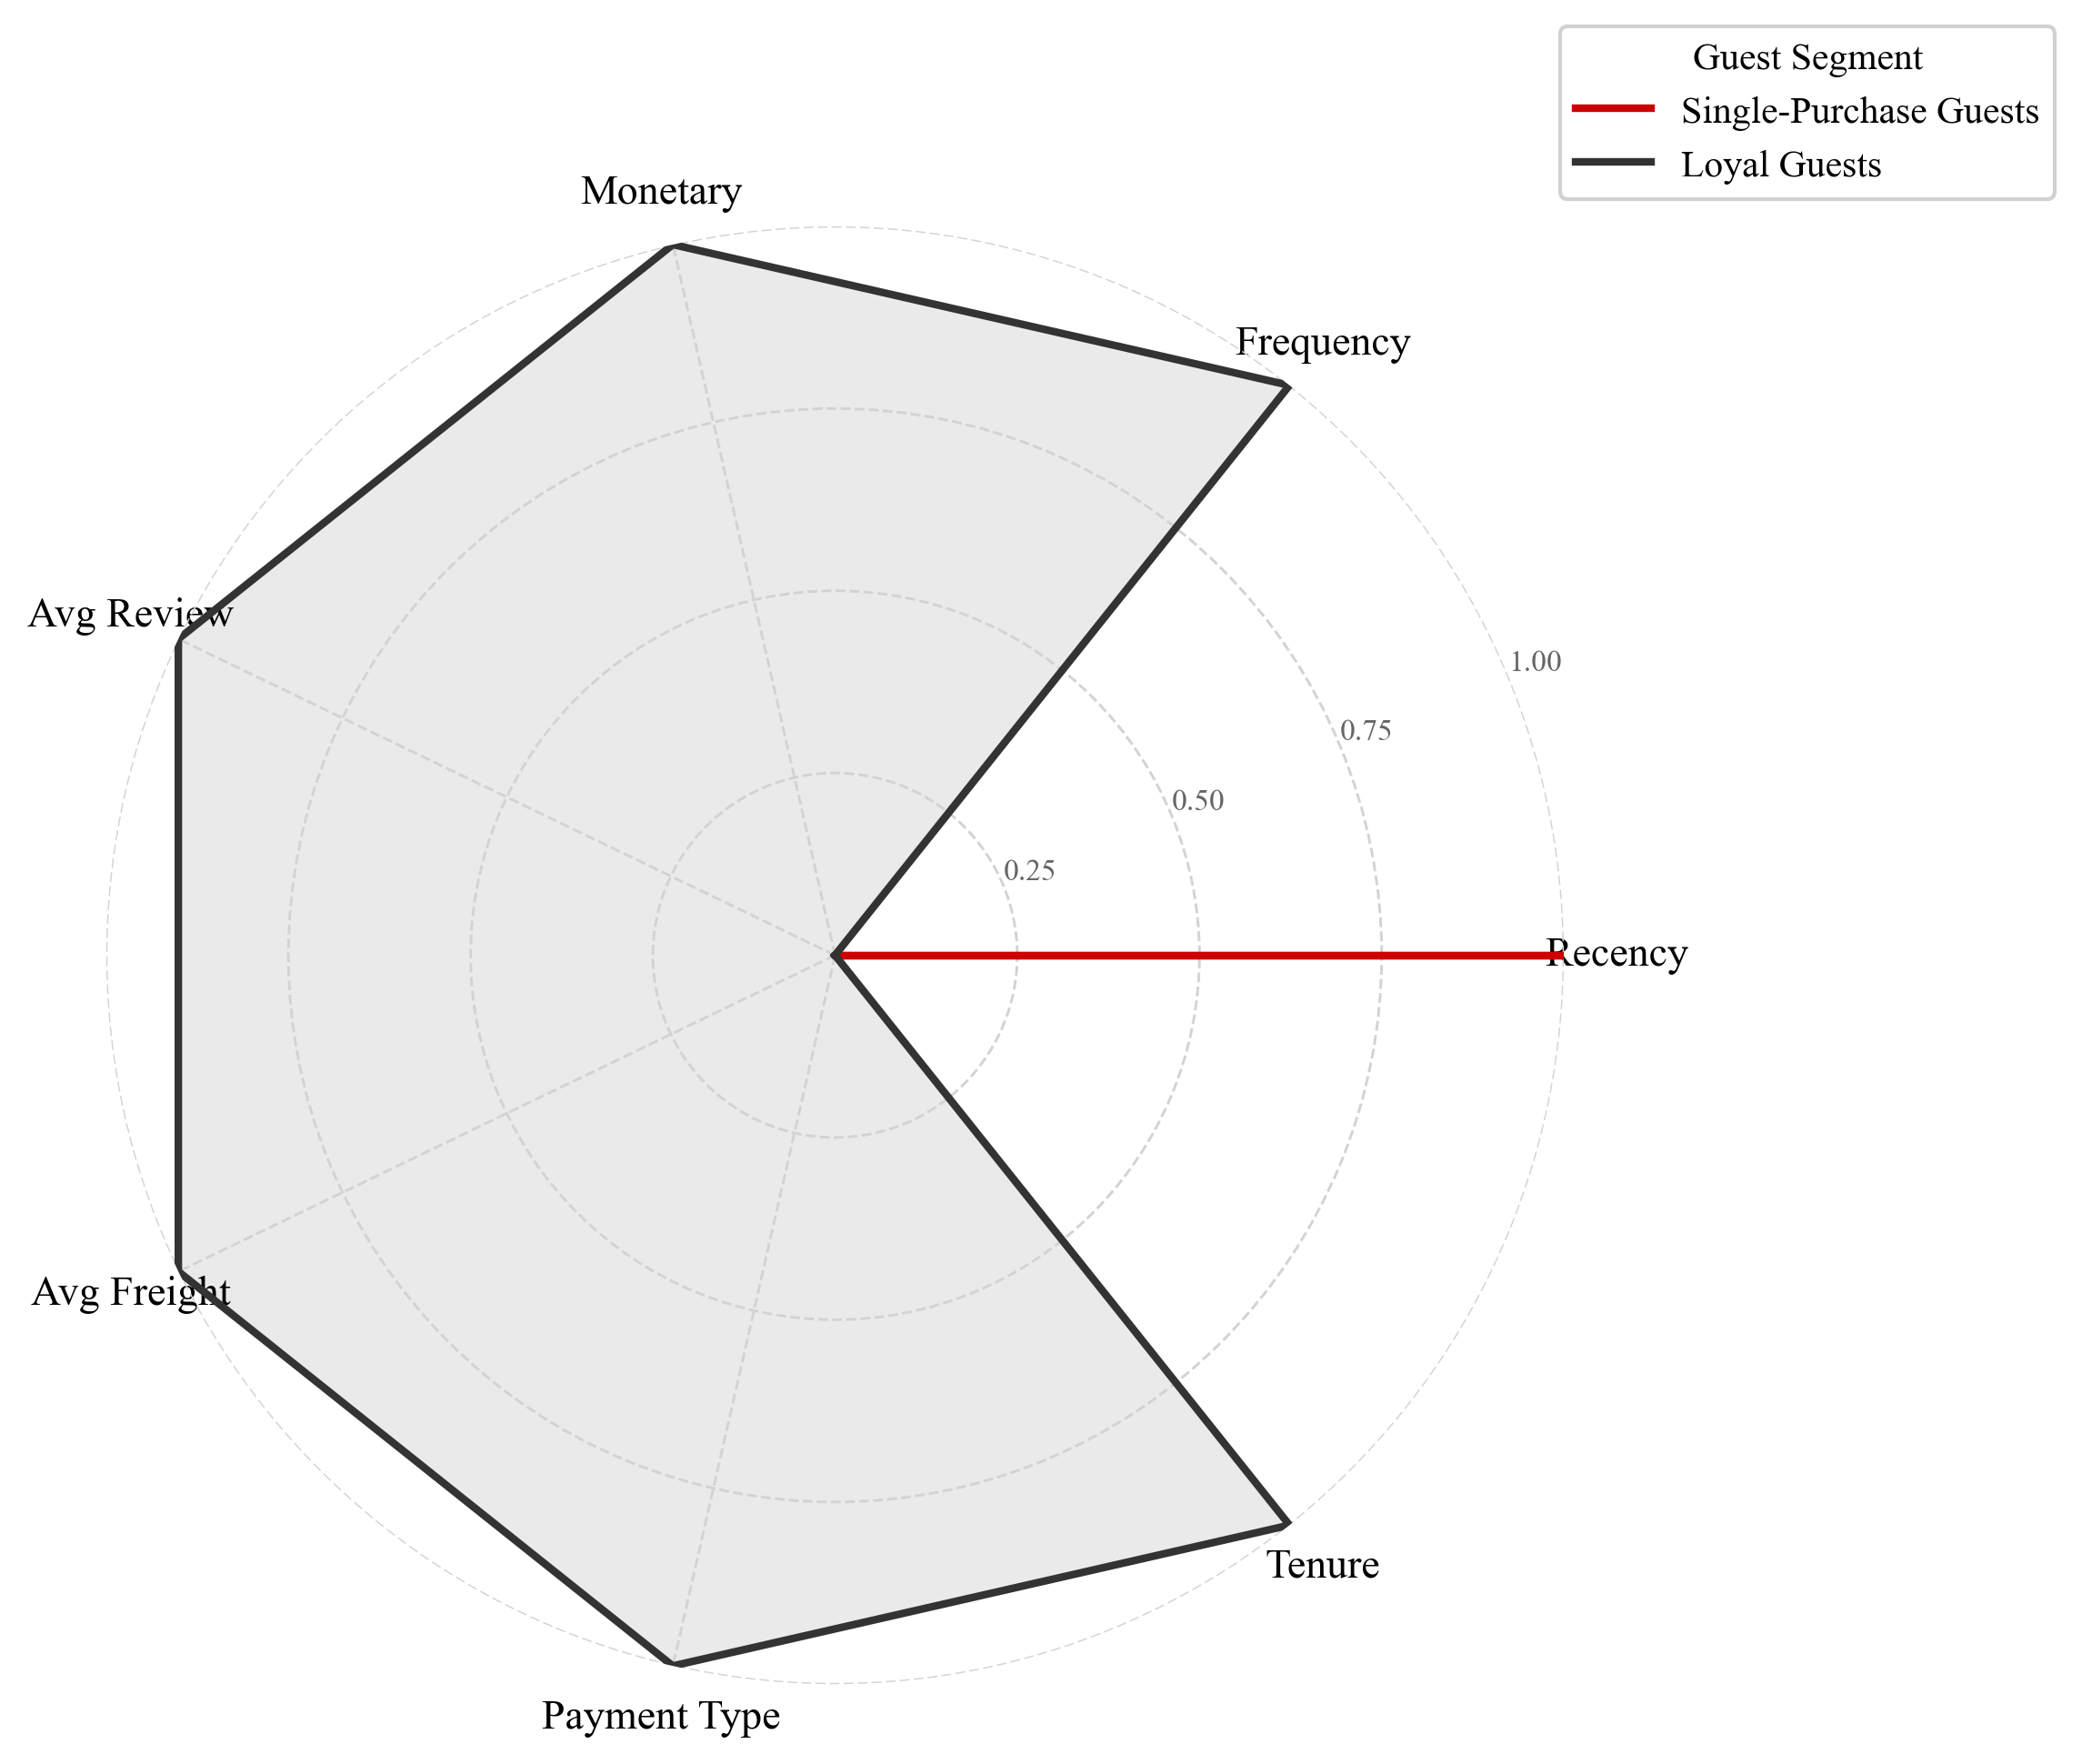

✅ Figure 10 saved.


In [9]:
# Radar Chart: Cluster Profiles (Figure 10)

profile_raw = df_raw.groupby("Cluster_Label")[FEATURES].mean()
profile_raw = profile_raw.loc[["Single-Purchase Guests", "Loyal Guests"]]

profile_norm = (profile_raw - profile_raw.min()) / (profile_raw.max() - profile_raw.min())

num_vars = len(FEATURES)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

label_aliases = [
    "Recency", "Frequency", "Monetary",
    "Avg Review", "Avg Freight", "Payment Type", "Tenure"
]

colors_radar = {
    "Single-Purchase Guests": "#CC0000",
    "Loyal Guests":           "#333333"
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for label, color in colors_radar.items():
    values = profile_norm.loc[label].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle="solid", label=label)
    ax.fill(angles, values, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(label_aliases, fontsize=11)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8, color=TARGET_GRAY)
ax.set_ylim(0, 1)
ax.grid(color="lightgray", linestyle="--", linewidth=0.7)
ax.spines["polar"].set_visible(False)

ax.legend(
    loc="upper right", bbox_to_anchor=(1.35, 1.15),
    fontsize=10, title="Guest Segment", title_fontsize=10,
    framealpha=0.9
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig10_radar_cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 10 saved.")

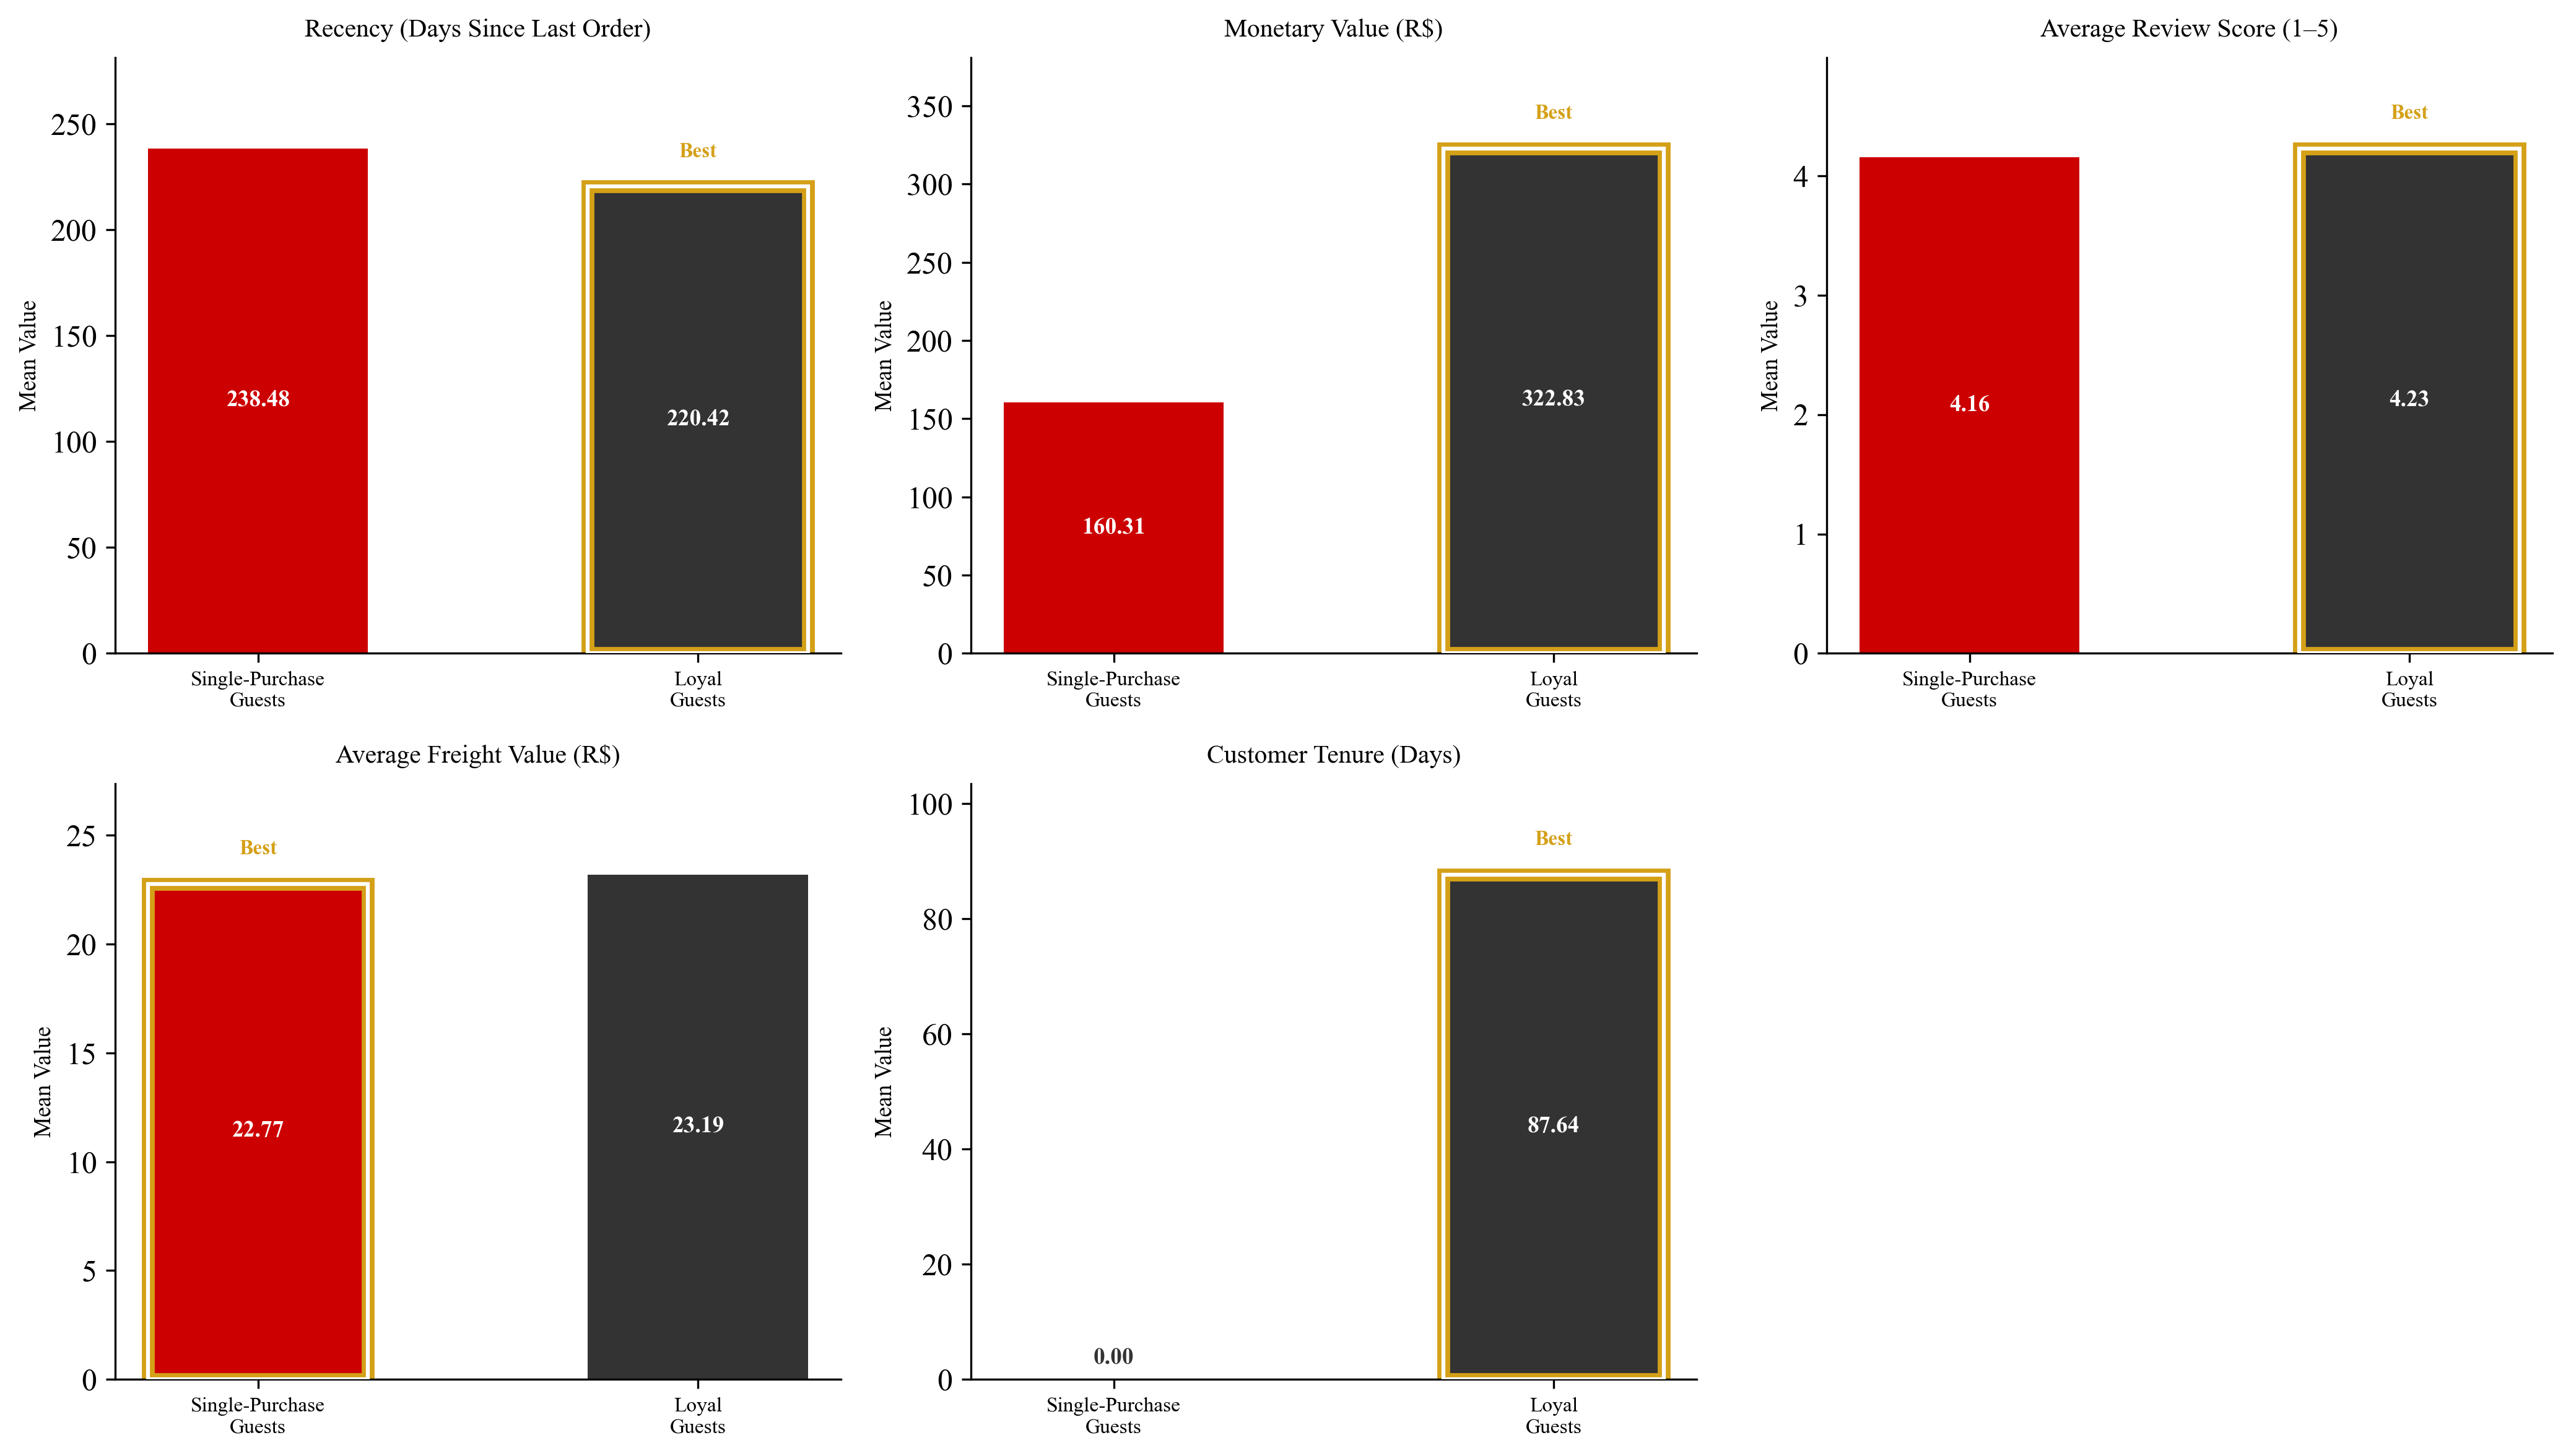

✅ Figure 11 saved.


In [10]:
# Feature Comparison Bar Charts (Figure 11)

segment_order = ["Single-Purchase Guests", "Loyal Guests"]
bar_colors    = ["#CC0000", "#333333"]

plot_features = {
    "Recency":     "Recency (Days Since Last Order)",
    "Monetary":    "Monetary Value (R$)",
    "Avg_Review":  "Average Review Score (1–5)",
    "Avg_Freight": "Average Freight Value (R$)",
    "Tenure":      "Customer Tenure (Days)"
}

best_is_highest = {
    "Recency":     False,
    "Monetary":    True,
    "Avg_Review":  True,
    "Avg_Freight": False,
    "Tenure":      True,
}

GOLD = "#D4A017"

def label_color_and_position(bar, val, max_val):
    threshold = max_val * 0.25
    if val >= threshold:
        return "white", bar.get_height() * 0.5, "center"
    else:
        return "#333333", bar.get_height() + max_val * 0.02, "bottom"

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, (feature, xlabel) in enumerate(plot_features.items()):
    ax = axes[idx]
    vals = [profile_raw.loc[seg, feature] for seg in segment_order]
    max_val = max(vals)

    if best_is_highest[feature]:
        best_idx = int(np.argmax(vals))
    else:
        best_idx = int(np.argmin(vals))

    bars = ax.bar(segment_order, vals, color=bar_colors, width=0.5, edgecolor="none")

    for i, (bar, val) in enumerate(zip(bars, vals)):
        if i == best_idx:
            bar.set_edgecolor(GOLD)
            bar.set_linewidth(5)
            ax.bar(
                bar.get_x() + bar.get_width() / 2,
                val, width=0.5,
                color="none", edgecolor="white",
                linewidth=1.5, zorder=5
            )

        color, y_pos, va = label_color_and_position(bar, val, max_val)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos, f"{val:,.2f}",
            ha="center", va=va,
            fontsize=9, color=color, fontweight="bold", zorder=6
        )

        if i == best_idx:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_val * 0.05,
                "Best", ha="center", va="bottom",
                fontsize=8, color=GOLD, fontweight="bold"
            )

    ax.set_ylim(0, max_val * 1.18)
    ax.set_title(xlabel, fontsize=10, pad=8)
    ax.set_xticks(range(len(segment_order)))
    ax.set_xticklabels(
        ["Single-Purchase\nGuests", "Loyal\nGuests"],
        fontsize=8
    )
    ax.set_ylabel("Mean Value", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[5].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig11_feature_bar_charts.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 11 saved.")

In [11]:
# Export Outputs

output_path = f"{OUTPUT_DIR}/rfm_clustered_table.csv"
df_raw.to_csv(output_path, index=False)
print(f"✅ Clustered dataset saved → {output_path}")
print(f"   Columns: {list(df_raw.columns)}")
print(f"   Rows:    {len(df_raw):,}")

import os
figures = [
    "fig7_correlation_matrix.png",
    "fig8_elbow_method.png",
    "fig9_silhouette_scores.png",
    "fig10_radar_cluster_profiles.png",
    "fig11_feature_bar_charts.png"
]

print(f"\nOutput file check:")
print("-" * 45)
for fname in figures:
    fpath = f"{OUTPUT_DIR}/{fname}"
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) // 1024 if exists else 0
    status = "✅" if exists else "❌"
    print(f"  {status}  {fname}  ({size} KB)")

print(f"\nModel Summary:")
print("-" * 45)
print(f"  Algorithm:        K-Means (k-means++ init)")
print(f"  Optimal K:        2")
print(f"  Inertia:          541,515.2")
print(f"  Silhouette Score: 0.632")
print(f"  Iterations:       3")
print(f"  Random State:     42")
print(f"  Total Guests:     {len(df_raw):,}")
print(f"\nCluster Breakdown:")
for label in ["Single-Purchase Guests", "Loyal Guests"]:
    n   = (df_raw["Cluster_Label"] == label).sum()
    pct = n / len(df_raw) * 100
    print(f"  {label:<30} {n:>6,}  ({pct:.1f}%)")

print("\n✅ All outputs verified. Notebook complete.")

✅ Clustered dataset saved → ../outputs/rfm_clustered_table.csv
   Columns: ['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Avg_Review', 'Avg_Freight', 'Payment_Type', 'Tenure', 'Payment_Type_Encoded', 'Cluster', 'Cluster_Label']
   Rows:    93,357

Output file check:
---------------------------------------------
  ✅  fig7_correlation_matrix.png  (348 KB)
  ✅  fig8_elbow_method.png  (160 KB)
  ✅  fig9_silhouette_scores.png  (123 KB)
  ✅  fig10_radar_cluster_profiles.png  (255 KB)
  ✅  fig11_feature_bar_charts.png  (210 KB)

Model Summary:
---------------------------------------------
  Algorithm:        K-Means (k-means++ init)
  Optimal K:        2
  Inertia:          541,515.2
  Silhouette Score: 0.632
  Iterations:       3
  Random State:     42
  Total Guests:     93,357

Cluster Breakdown:
  Single-Purchase Guests         90,551  (97.0%)
  Loyal Guests                    2,806  (3.0%)

✅ All outputs verified. Notebook complete.


In [12]:
# Supervised Models: Predicting Avg_Review (Cluster 0 — Single-Purchase Guests)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

# ── Subset to Cluster 0 only ──────────────────────────────────
cluster0 = df_raw[df_raw["Cluster_Label"] == "Single-Purchase Guests"].copy()
print(f"✅ Cluster 0 subset: {len(cluster0):,} guests")

# ── Features and target ───────────────────────────────────────
FEATURE_COLS = ["Recency", "Frequency", "Monetary", "Avg_Freight",
                "Payment_Type_Encoded", "Tenure"]
TARGET_COL   = "Avg_Review"

X = cluster0[FEATURE_COLS].values
y = cluster0[TARGET_COL].values

print(f"   Features: {FEATURE_COLS}")
print(f"   Target:   {TARGET_COL}")
print(f"   y mean:   {y.mean():.4f}  |  y std: {y.std():.4f}")
print(f"   y min:    {y.min():.1f}   |  y max: {y.max():.1f}")

✅ Cluster 0 subset: 90,551 guests
   Features: ['Recency', 'Frequency', 'Monetary', 'Avg_Freight', 'Payment_Type_Encoded', 'Tenure']
   Target:   Avg_Review
   y mean:   4.1581  |  y std: 1.2835
   y min:    1.0   |  y max: 5.0


In [14]:
# Decision Tree, Random Forest, XGBoost predicting Monetary (Cluster 0)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

# ── Subset to Cluster 0 only ──────────────────────────────────
cluster0 = df_raw[df_raw["Cluster_Label"] == "Single-Purchase Guests"].copy()
print(f"✅ Cluster 0 subset: {len(cluster0):,} guests")

# ── Features and target ───────────────────────────────────────
FEATURE_COLS = ["Recency", "Frequency", "Avg_Review",
                "Avg_Freight", "Payment_Type_Encoded", "Tenure"]
TARGET_COL   = "Monetary"

X = cluster0[FEATURE_COLS].values

# ── Log-transform Monetary to handle right skew ───────────────
y_raw = cluster0[TARGET_COL].values
y     = np.log1p(y_raw)

print(f"   Features:      {FEATURE_COLS}")
print(f"   Target:        {TARGET_COL} (log-transformed)")
print(f"   y_raw mean:    R${y_raw.mean():.2f}  |  y_raw max: R${y_raw.max():,.2f}")
print(f"   y_log mean:    {y.mean():.4f}  |  y_log std: {y.std():.4f}")

# ── Models ────────────────────────────────────────────────────
PARTITIONS = [
    ("70/30", 0.30),
    ("80/20", 0.20),
    ("95/5",  0.05)
]

MODELS = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":       XGBRegressor(n_estimators=100, random_state=42,
                                   verbosity=0, eval_metric="rmse")
}

results = []

print(f"\n{'Model':<18} {'Split':<8} {'Train N':>8} {'Test N':>8} "
      f"{'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 72)

for split_label, test_size in PARTITIONS:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    for model_name, model in MODELS.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Metrics on log scale
        rmse = mean_squared_error(y_test, y_pred) ** 0.5
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        # Back-transform for interpretability
        rmse_brl = np.expm1(rmse)

        results.append({
            "Model":    model_name,
            "Split":    split_label,
            "Train_N":  len(X_train),
            "Test_N":   len(X_test),
            "RMSE":     round(rmse, 4),
            "MAE":      round(mae, 4),
            "R2":       round(r2, 4),
            "RMSE_BRL": round(rmse_brl, 2)
        })

        print(f"{model_name:<18} {split_label:<8} {len(X_train):>8,} {len(X_test):>8,} "
              f"{rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

df_results = pd.DataFrame(results)
print("\n✅ All models complete.")
print("\nRMSE back-transformed to R$ (approximate real-world error):")
print("-" * 45)
for _, row in df_results.iterrows():
    print(f"  {row['Model']:<18} {row['Split']:<8}  ≈ R${row['RMSE_BRL']:,.2f}")

✅ Cluster 0 subset: 90,551 guests
   Features:      ['Recency', 'Frequency', 'Avg_Review', 'Avg_Freight', 'Payment_Type_Encoded', 'Tenure']
   Target:        Monetary (log-transformed)
   y_raw mean:    R$160.31  |  y_raw max: R$6,081.54
   y_log mean:    4.7060  |  y_log std: 0.8003

Model              Split     Train N   Test N     RMSE      MAE       R²
------------------------------------------------------------------------
Decision Tree      70/30      63,385   27,166   0.6258   0.3900   0.3834
Random Forest      70/30      63,385   27,166   0.4806   0.3266   0.6362
XGBoost            70/30      63,385   27,166   0.5036   0.3635   0.6007
Decision Tree      80/20      72,440   18,111   0.6228   0.3853   0.3957
Random Forest      80/20      72,440   18,111   0.4842   0.3272   0.6348
XGBoost            80/20      72,440   18,111   0.5069   0.3648   0.5997
Decision Tree      95/5       86,023    4,528   0.6193   0.3835   0.4039
Random Forest      95/5       86,023    4,528   0.4813   

In [15]:
# Decision Tree, Random Forest, XGBoost predicting Monetary (Cluster 1 — Loyal Guests)

cluster1 = df_raw[df_raw["Cluster_Label"] == "Loyal Guests"].copy()
print(f"✅ Cluster 1 subset: {len(cluster1):,} guests")

X1 = cluster1[FEATURE_COLS].values

y1_raw = cluster1[TARGET_COL].values
y1     = np.log1p(y1_raw)

print(f"   Features:      {FEATURE_COLS}")
print(f"   Target:        {TARGET_COL} (log-transformed)")
print(f"   y_raw mean:    R${y1_raw.mean():.2f}  |  y_raw max: R${y1_raw.max():,.2f}")
print(f"   y_log mean:    {y1.mean():.4f}  |  y_log std: {y1.std():.4f}")

results1 = []

print(f"\n{'Model':<18} {'Split':<8} {'Train N':>8} {'Test N':>8} "
      f"{'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 72)

for split_label, test_size in PARTITIONS:
    X1_train, X1_test, y1_train, y1_test = train_test_split(
        X1, y1, test_size=test_size, random_state=42
    )
    for model_name, model_class in [
        ("Decision Tree", DecisionTreeRegressor(random_state=42)),
        ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        ("XGBoost",       XGBRegressor(n_estimators=100, random_state=42,
                                        verbosity=0, eval_metric="rmse"))
    ]:
        model_class.fit(X1_train, y1_train)
        y1_pred = model_class.predict(X1_test)

        rmse = mean_squared_error(y1_test, y1_pred) ** 0.5
        mae  = mean_absolute_error(y1_test, y1_pred)
        r2   = r2_score(y1_test, y1_pred)
        rmse_brl = np.expm1(rmse)

        results1.append({
            "Model":    model_name,
            "Split":    split_label,
            "Train_N":  len(X1_train),
            "Test_N":   len(X1_test),
            "RMSE":     round(rmse, 4),
            "MAE":      round(mae, 4),
            "R2":       round(r2, 4),
            "RMSE_BRL": round(rmse_brl, 2)
        })

        print(f"{model_name:<18} {split_label:<8} {len(X1_train):>8,} {len(X1_test):>8,} "
              f"{rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

df_results1 = pd.DataFrame(results1)
print("\n✅ All Cluster 1 models complete.")
print("\nRMSE back-transformed to R$ (approximate real-world error):")
print("-" * 45)
for _, row in df_results1.iterrows():
    print(f"  {row['Model']:<18} {row['Split']:<8}  ≈ R${row['RMSE_BRL']:,.2f}")

✅ Cluster 1 subset: 2,806 guests
   Features:      ['Recency', 'Frequency', 'Avg_Review', 'Avg_Freight', 'Payment_Type_Encoded', 'Tenure']
   Target:        Monetary (log-transformed)
   y_raw mean:    R$322.83  |  y_raw max: R$13,664.08
   y_log mean:    5.4748  |  y_log std: 0.7055

Model              Split     Train N   Test N     RMSE      MAE       R²
------------------------------------------------------------------------
Decision Tree      70/30       1,964      842   0.7127   0.5514  -0.0942
Random Forest      70/30       1,964      842   0.5258   0.4159   0.4045
XGBoost            70/30       1,964      842   0.5809   0.4562   0.2730
Decision Tree      80/20       2,244      562   0.7115   0.5624  -0.0335
Random Forest      80/20       2,244      562   0.5238   0.4187   0.4399
XGBoost            80/20       2,244      562   0.5845   0.4664   0.3025
Decision Tree      95/5        2,665      141   0.7173   0.5677   0.0190
Random Forest      95/5        2,665      141   0.5306   

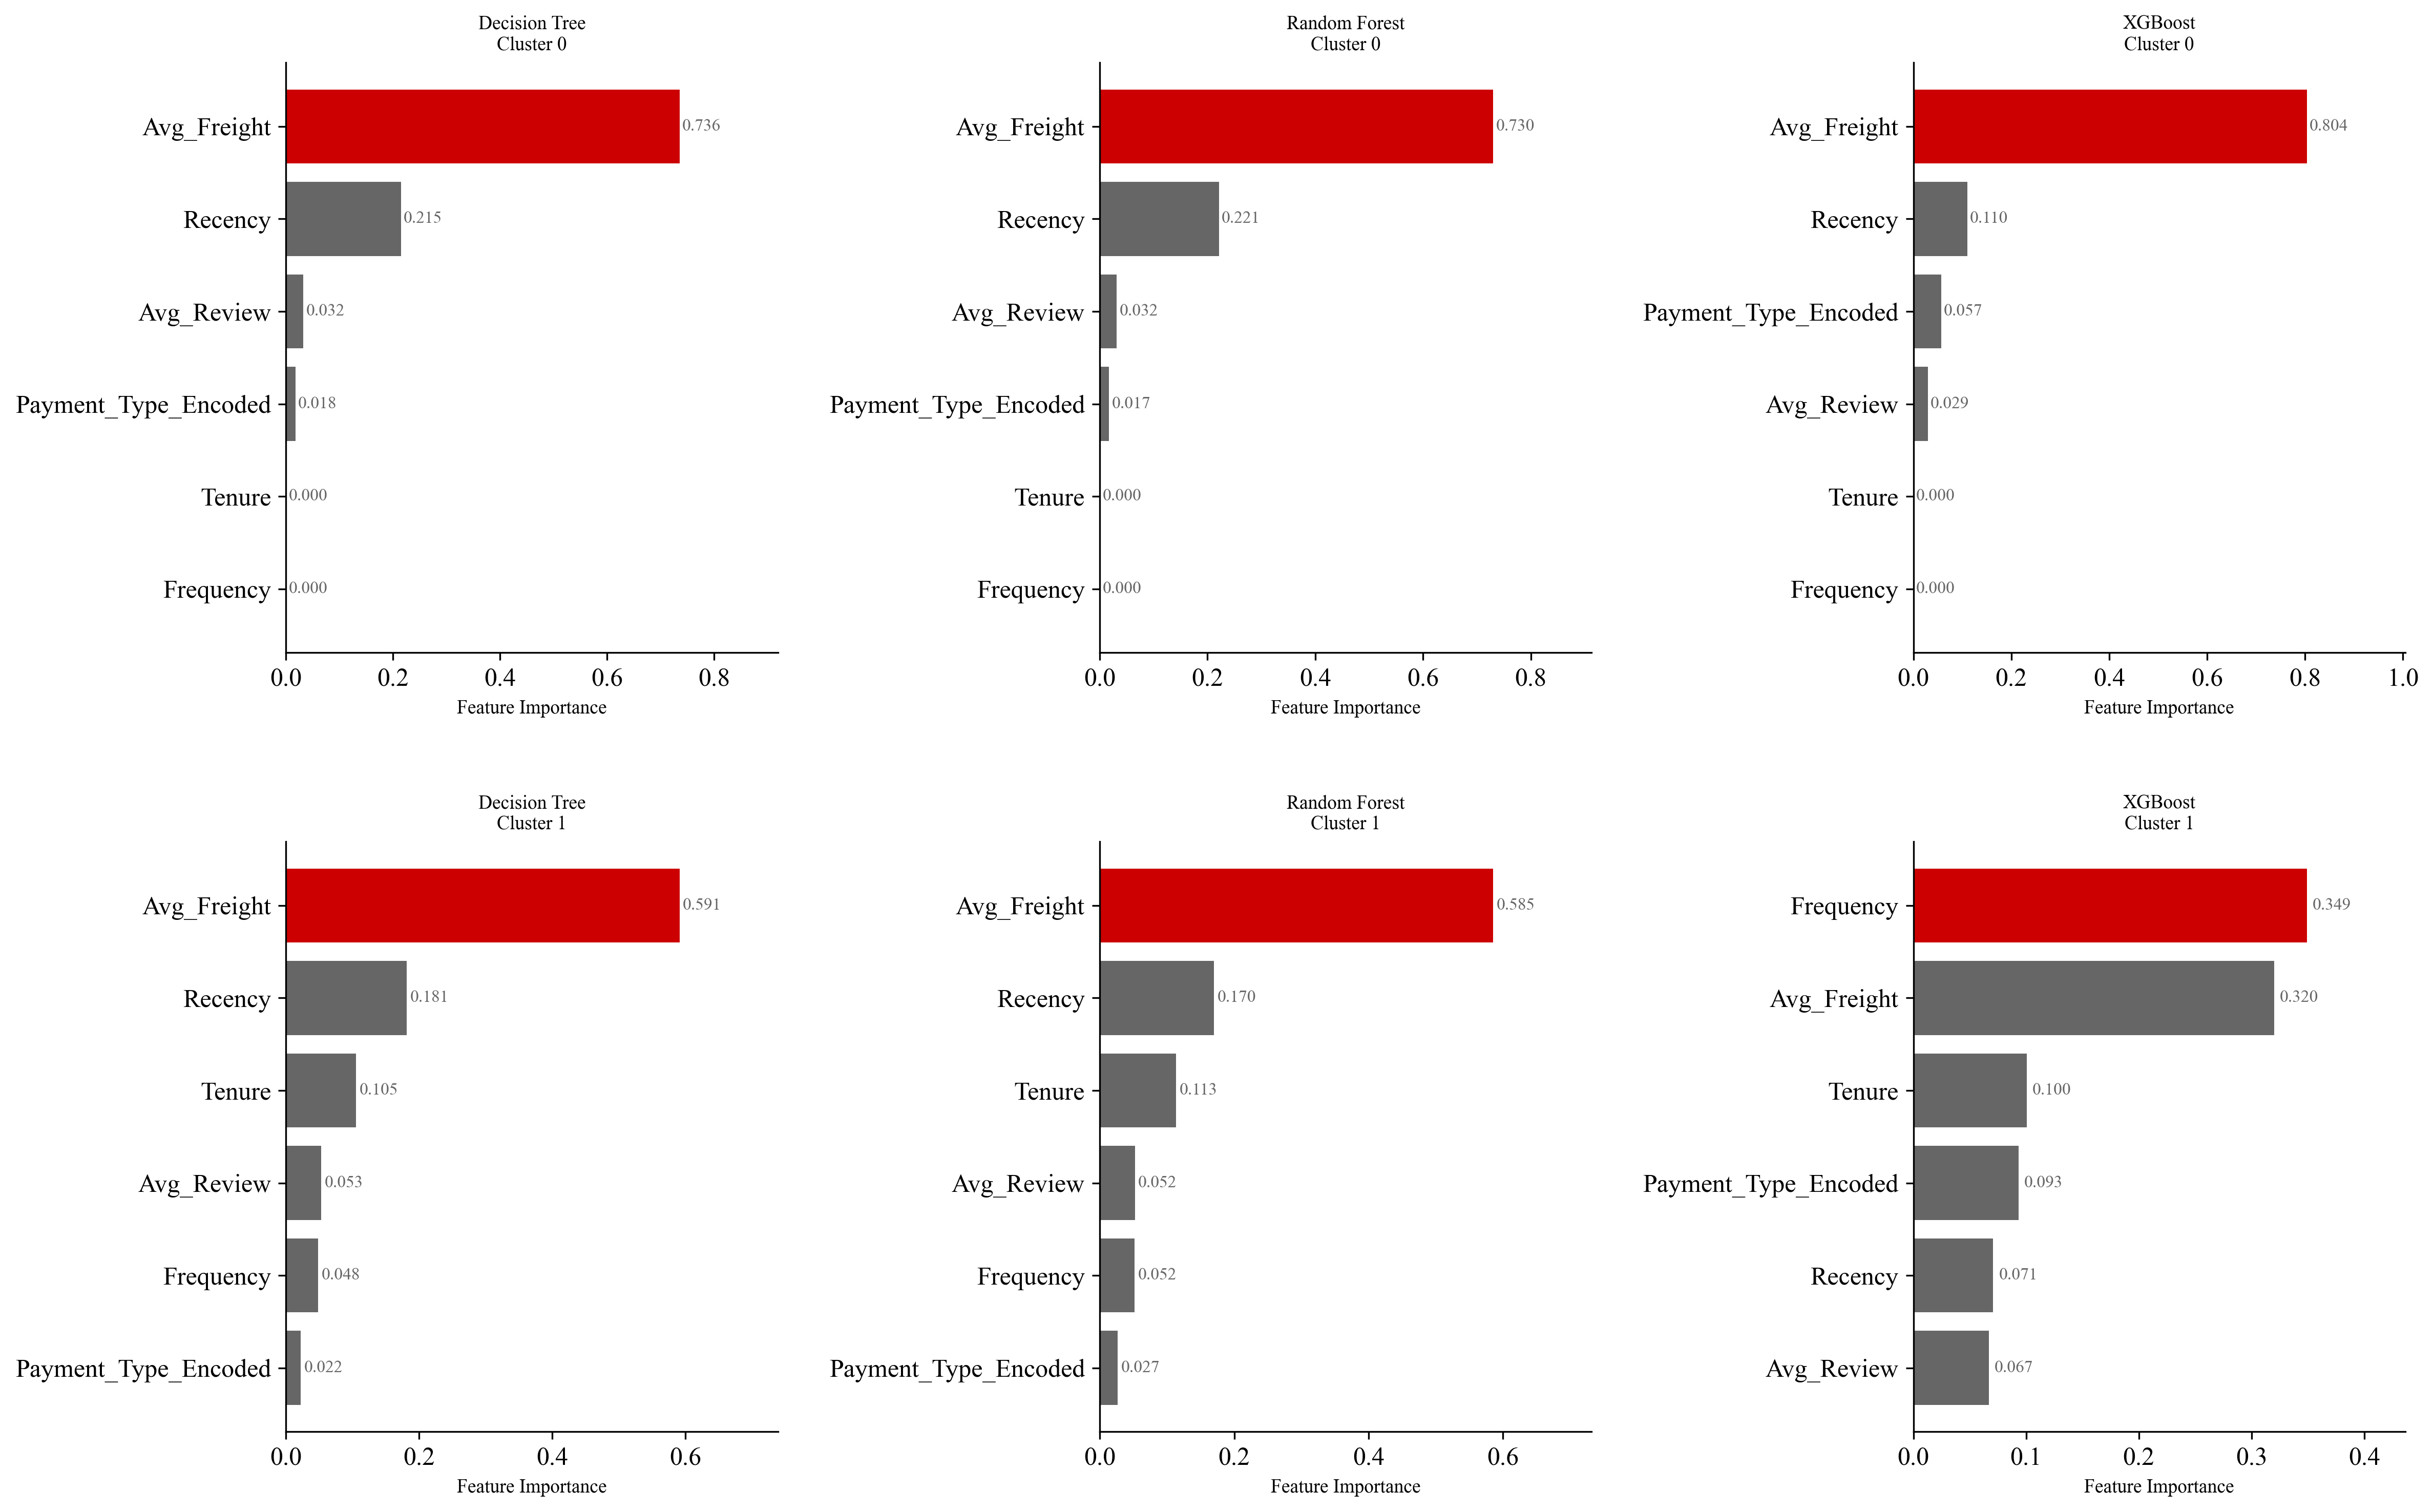

✅ Figure 12 saved.

COMBINED RESULTS — Predicting Monetary Value (Log-Transformed)

Cluster      Model              Split        RMSE      MAE       R²
-----------------------------------------------------------------
Cluster 0    Decision Tree      70/30      0.6258   0.3900   0.3834
Cluster 0    Random Forest      70/30      0.4806   0.3266   0.6362
Cluster 0    XGBoost            70/30      0.5036   0.3635   0.6007
Cluster 0    Decision Tree      80/20      0.6228   0.3853   0.3957
Cluster 0    Random Forest      80/20      0.4842   0.3272   0.6348
Cluster 0    XGBoost            80/20      0.5069   0.3648   0.5997
Cluster 0    Decision Tree      95/5       0.6193   0.3835   0.4039
Cluster 0    Random Forest      95/5       0.4813   0.3245   0.6399
Cluster 0    XGBoost            95/5       0.5004   0.3590   0.6108

Cluster 1    Decision Tree      70/30      0.7127   0.5514  -0.0942
Cluster 1    Random Forest      70/30      0.5258   0.4159   0.4045
Cluster 1    XGBoost            7

In [ ]:
# Feature Importance Visualization (Figure 12)

# ── Re-fit models on 80/20 split for feature importance ──────
# Using 80/20 as the canonical split for visualization

splits = {}
for cluster_name, X_data, y_data in [
    ("Cluster 0 — Single-Purchase Guests", X, y),
    ("Cluster 1 — Loyal Guests", X1, y1)
]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_data, y_data, test_size=0.20, random_state=42
    )
    splits[cluster_name] = (X_tr, X_te, y_tr, y_te)

# Models to visualize — DT and RF have native feature importance
# XGBoost also has feature importance
viz_models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":       XGBRegressor(n_estimators=100, random_state=42,
                                   verbosity=0, eval_metric="rmse")
}

feature_names = FEATURE_COLS
cluster_labels = list(splits.keys())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row_idx, cluster_name in enumerate(cluster_labels):
    X_tr, X_te, y_tr, y_te = splits[cluster_name]

    for col_idx, (model_name, model) in enumerate(viz_models.items()):
        ax = axes[row_idx][col_idx]
        model.fit(X_tr, y_tr)

        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        sorted_features = [feature_names[i] for i in indices]
        sorted_importances = importances[indices]

        colors_bar = [TARGET_RED if i == 0 else TARGET_GRAY
                      for i in range(len(sorted_features))]

        bars = ax.barh(sorted_features[::-1],
                       sorted_importances[::-1],
                       color=colors_bar[::-1],
                       edgecolor="none")

        # Value labels
        for bar, val in zip(bars, sorted_importances[::-1]):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=8, color=TARGET_GRAY)

        ax.set_xlim(0, max(importances) * 1.25)
        ax.set_xlabel("Feature Importance", fontsize=9)
        ax.set_title(f"{model_name}\n{cluster_name.split('—')[0].strip()}",
                     fontsize=9, pad=6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.tight_layout(h_pad=3, w_pad=2)
plt.savefig(f"{OUTPUT_DIR}/fig12_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 12 saved.")

# ── Results comparison table ──────────────────────────────────
print("\n" + "=" * 85)
print("COMBINED RESULTS — Predicting Monetary Value (Log-Transformed)")
print("=" * 85)
print(f"\n{'Cluster':<12} {'Model':<18} {'Split':<8} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 65)

for _, row in df_results.iterrows():
    print(f"{'Cluster 0':<12} {row['Model']:<18} {row['Split']:<8} "
          f"{row['RMSE']:>8.4f} {row['MAE']:>8.4f} {row['R2']:>8.4f}")

print()
for _, row in df_results1.iterrows():
    print(f"{'Cluster 1':<12} {row['Model']:<18} {row['Split']:<8} "
          f"{row['RMSE']:>8.4f} {row['MAE']:>8.4f} {row['R2']:>8.4f}")

print("\n✅ Combined results table complete.")

In [17]:
# Final Export

# ── Save results tables to CSV ────────────────────────────────
results_path0 = f"{OUTPUT_DIR}/model_results_cluster0.csv"
results_path1 = f"{OUTPUT_DIR}/model_results_cluster1.csv"
combined_path = f"{OUTPUT_DIR}/model_results_combined.csv"

df_results["Cluster"] = "Cluster 0 — Single-Purchase Guests"
df_results1["Cluster"] = "Cluster 1 — Loyal Guests"
df_combined = pd.concat([df_results, df_results1], ignore_index=True)

df_results.to_csv(results_path0, index=False)
df_results1.to_csv(results_path1, index=False)
df_combined.to_csv(combined_path, index=False)

print("✅ Results tables saved:")
print(f"   → {results_path0}")
print(f"   → {results_path1}")
print(f"   → {combined_path}")

# ── Save clustered dataset ────────────────────────────────────
output_path = f"{OUTPUT_DIR}/rfm_clustered_table.csv"
df_raw.to_csv(output_path, index=False)
print(f"\n✅ Clustered dataset saved → {output_path}")

# ── Full output file check ────────────────────────────────────
all_files = [
    "fig7_correlation_matrix.png",
    "fig8_elbow_method.png",
    "fig9_silhouette_scores.png",
    "fig10_radar_cluster_profiles.png",
    "fig11_feature_bar_charts.png",
    "fig12_feature_importance.png",
    "rfm_clustered_table.csv",
    "model_results_cluster0.csv",
    "model_results_cluster1.csv",
    "model_results_combined.csv"
]

print(f"\nFull output file check:")
print("-" * 50)
for fname in all_files:
    fpath = f"{OUTPUT_DIR}/{fname}"
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) // 1024 if exists else 0
    status = "✅" if exists else "❌"
    print(f"  {status}  {fname}  ({size} KB)")

# ── Final model summary ───────────────────────────────────────
print(f"\n{'='*60}")
print("FINAL MODEL SUMMARY")
print(f"{'='*60}")
print(f"\nClustering:")
print(f"  Algorithm:        K-Means (k-means++ init)")
print(f"  K:                2")
print(f"  Silhouette Score: 0.632")
print(f"  Cluster 0:        90,551 Single-Purchase Guests (97.0%)")
print(f"  Cluster 1:         2,806 Loyal Guests (3.0%)")

print(f"\nSupervised Models — Target: Monetary (log-transformed)")
print(f"  Best overall:     Random Forest — Cluster 0 R²=0.636, Cluster 1 R²=0.440")
print(f"  Splits tested:    70/30, 80/20, 95/5")
print(f"  Top feature:      Avg_Freight (dominant in both clusters)")

print("\n✅ Notebook complete. All outputs verified.")

✅ Results tables saved:
   → ../outputs/model_results_cluster0.csv
   → ../outputs/model_results_cluster1.csv
   → ../outputs/model_results_combined.csv

✅ Clustered dataset saved → ../outputs/rfm_clustered_table.csv

Full output file check:
--------------------------------------------------
  ✅  fig7_correlation_matrix.png  (348 KB)
  ✅  fig8_elbow_method.png  (160 KB)
  ✅  fig9_silhouette_scores.png  (123 KB)
  ✅  fig10_radar_cluster_profiles.png  (255 KB)
  ✅  fig11_feature_bar_charts.png  (210 KB)
  ✅  fig12_feature_importance.png  (286 KB)
  ✅  rfm_clustered_table.csv  (8725 KB)
  ✅  model_results_cluster0.csv  (0 KB)
  ✅  model_results_cluster1.csv  (0 KB)
  ✅  model_results_combined.csv  (1 KB)

FINAL MODEL SUMMARY

Clustering:
  Algorithm:        K-Means (k-means++ init)
  K:                2
  Silhouette Score: 0.632
  Cluster 0:        90,551 Single-Purchase Guests (97.0%)
  Cluster 1:         2,806 Loyal Guests (3.0%)

Supervised Models — Target: Monetary (log-transformed)
 